#Imports

In [ ]:
!pip install pandas matplotlib seaborn scikit-learn tensorflow numpy tqdm kagglehub

In [ ]:
import pandas as pd
import os
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import load_model
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.optimizers import SGD
from tqdm import tqdm
import kagglehub

#Download Dataset

Kaggle Dataset: Breast Cancer Ultrasound Images - Arya Shah

In [ ]:
# Download latest version
path = kagglehub.dataset_download("aryashah2k/breast-ultrasound-images-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'breast-ultrasound-images-dataset' dataset.
Path to dataset files: /kaggle/input/breast-ultrasound-images-dataset


Create a new folder for easier access to the dataset

In [ ]:
!rm -r /content/dataset
!mkdir /content/dataset

!cp -r "/kaggle/input/breast-ultrasound-images-dataset" /content/dataset

Prepares data for dataframe

In [ ]:
train_path = "/content/dataset/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT"

data = []

for label in os.listdir(train_path):

    label_path = os.path.join(train_path, label)

    if os.path.isdir(label_path):

        for file in os.listdir(label_path):

            if file.endswith(".png"):

                data.append({
                    "filepath": os.path.join(label_path, file),
                    "label": label
                })

#Dataframe Initialization

In [ ]:
df = pd.DataFrame(data)

print("training images:", len(df))

df

training images: 1578


,filepath,label
0,/content/dataset/breast-ultrasound-images-data...,malignant
1,/content/dataset/breast-ultrasound-images-data...,malignant
2,/content/dataset/breast-ultrasound-images-data...,malignant
3,/content/dataset/breast-ultrasound-images-data...,malignant
4,/content/dataset/breast-ultrasound-images-data...,malignant
...,...,...
1573,/content/dataset/breast-ultrasound-images-data...,normal
1574,/content/dataset/breast-ultrasound-images-data...,normal
1575,/content/dataset/breast-ultrasound-images-data...,normal
1576,/content/dataset/breast-ultrasound-images-data...,normal


#Class Weights

Since the distribution between each cloud type is not uniform (2.7x difference between largest and smallest), class weights will allow for the smaller classes to have more importance for training the model

In [ ]:
class_weights = {
    0: 1.0,  # Benign
    1: 2.3,  # Malignant
    2: 1.2   # Normal
}

print("class weights:", class_weights)

class weights: {0: 1.0, 1: 2.3, 2: 1.2}


#Train Test Validation Split

In [ ]:
X = df["filepath"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size = 0.2,
    stratify=y_train,
    random_state=42
)


#Base ResNet50 Model

Parameters:

- weights: imagenet - automatic weights from ResNet50
- include_top: False - removes final FC layers
- input_shape: 200x200px, 3 dimensions (3 classes)

In [ ]:
base_model = tf.keras.applications.ResNet50(weights='imagenet', include_top=False, input_shape=(200, 200, 3))

# Prevents destroying learned features of the ResNet50 Model
for layer in base_model.layers:
  layer.trainable = False


Make full CNN model from the base model

- ResNet50 feature vector size: 2048 neurons
- Intermediate dense layer: 128 neurons
- Neuron dropout: 30% - to prevent overfitting
- Output: 3 neurons (for 3 classes)

In [ ]:
# Grabs ResNet50 output after all conv
# Shape: (None, 11, 11, 2048)
x = base_model.output
print(x.shape)

# Converts Shape (None, 11, 11, 2048) into one 2048 length vector (None, 2048)
x = layers.GlobalAveragePooling2D()(x)

# Adds an intermediate FC layer
x = layers.Dense(128, activation='relu')(x)

# Neuron dropout (30%)
x = layers.Dropout(0.3)(x)

# Final classification layer; 3 classes = 3 layers
output = layers.Dense(3, activation='softmax')(x)

# Connect
model = models.Model(inputs=base_model.input, outputs=output)


(None, 7, 7, 2048)


#Image Preprocessing & Data Separation

Loads all images at 200x200px into train, val, and test data using the train-test-val split dataframes

In [ ]:
# Loads images, rescales pixel values to [0,1], train/val split
datagen = ImageDataGenerator(rescale=1./255)

train_df = pd.concat([X_train, y_train], axis=1)
val_df   = pd.concat([X_val, y_val], axis=1)
test_df = pd.concat([X_test, y_test], axis=1)

# Sends batches of 32 images for testing
train_data = datagen.flow_from_dataframe(
    train_df,
    x_col='filepath',
    y_col='label',
    target_size=(200, 200),
    batch_size=32,
    class_mode='categorical'
)

# Sends batches of 32 images for validation
val_data = datagen.flow_from_dataframe(
    val_df,
    x_col='filepath',
    y_col='label',
    target_size=(200, 200),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# Sends batches of 32 images for test
test_data = datagen.flow_from_dataframe(
    test_df,
    x_col='filepath',
    y_col='label',
    target_size=(200, 200),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 1009 validated image filenames belonging to 3 classes.
Found 253 validated image filenames belonging to 3 classes.
Found 316 validated image filenames belonging to 3 classes.


#Layers Frozen

In [ ]:
for layer in base_model.layers:
  layer.trainable = False

model.compile(Layer
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy', 'recall', 'precision']
)

model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

#Layers Unfrozen

In [ ]:
for layer in model.layers[-40:]:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss='categorical_crossentropy',
    metrics=['accuracy', 'recall', 'precision']
)

model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    class_weight=class_weights
)

#Save Model

In [ ]:
model.save("breast_cancer_model.keras")

from google.colab import files
files.download("/content/breast_cancer_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#Import Model

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving breast_cancer_model4.keras to breast_cancer_model4.keras


In [ ]:
# Uses saved model
model2 = load_model("breast_cancer_model4.keras")


#Final Model Metrics

The final model is imported in and is tested with the test data to obtain its performance metrics

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 186ms/step


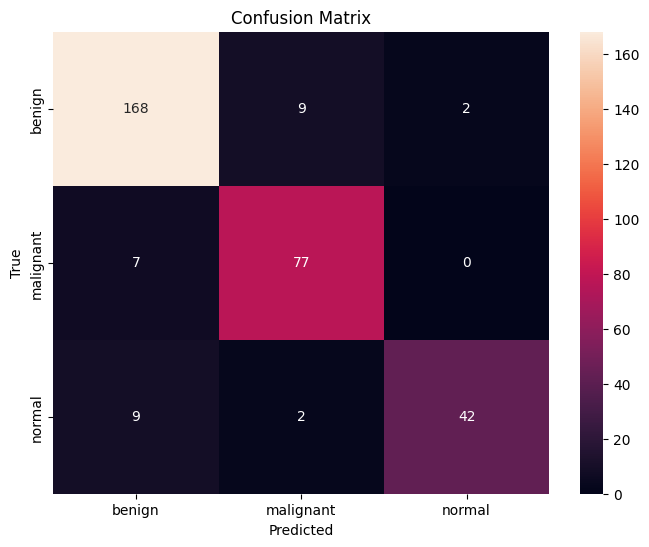

In [ ]:
pred_probs = model2.predict(test_data)
pred_classes = np.argmax(pred_probs, axis=1)
true_classes = test_data.classes

labels = list(test_data.class_indices.keys())
cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
print(classification_report(true_classes, pred_classes, target_names=labels))
print(cm)

              precision    recall  f1-score   support

      benign       0.91      0.94      0.93       179
   malignant       0.88      0.92      0.90        84
      normal       0.95      0.79      0.87        53

    accuracy                           0.91       316
   macro avg       0.91      0.88      0.90       316
weighted avg       0.91      0.91      0.91       316

[[168   9   2]
 [  7  77   0]
 [  9   2  42]]
